# Pipeline de Pré-processamento
**Objetivo:** Estruturar o pipeline de dados para excluir coluna que gerará ruído, montar os dados de treinamento/teste e transformar os textos em números.

In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import os

PROCESSED_PATH = '../data/processed/dataset_limpo.csv'

df = pd.read_csv(PROCESSED_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65231 entries, 0 to 65230
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Distribuidora         65231 non-null  object 
 1   Protocolo             65231 non-null  int64  
 2   Natureza              65231 non-null  object 
 3   Tipologia             65231 non-null  object 
 4   CanalEntrada          65231 non-null  object 
 5   tempo_resolucao_dias  65231 non-null  float64
 6   estourou_sla          65231 non-null  int64  
 7   dia_semana_abertura   65231 non-null  int64  
 8   hora_abertura         65231 non-null  int64  
 9   mes_abertura          65231 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 5.0+ MB


In [80]:
df = df.drop(columns=['Protocolo'])


In [81]:
X = df.drop(columns=["estourou_sla", "tempo_resolucao_dias"])
y = df["estourou_sla"]


In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Colunas que o modelo está usando para aprender:")
print(X_train.columns.tolist())

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Colunas que o modelo está usando para aprender:
['Distribuidora', 'Natureza', 'Tipologia', 'CanalEntrada', 'dia_semana_abertura', 'hora_abertura', 'mes_abertura']
Treino: 52184 amostras
Teste: 13047 amostras


In [83]:
colunas_de_texto = ['Distribuidora', 'Natureza', 'Tipologia', 'CanalEntrada']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_de_texto)
    ],
    remainder='passthrough'
)

# Pipeline de Treinamento
Utiliza o mesmo pre-processador para o tratamento dos dados e treina os dois modelos.

In [84]:
## Modelo de Classificação
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipeline_classificacao = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
('smote', SMOTE(random_state=42)), # Volta ao padrão (50/50)
    ('classifier', RandomForestClassifier(
        max_depth=12,            
        min_samples_leaf=3,      
        random_state=42
    ))
])

pipeline_classificacao.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Distribuidora', 'Natureza',
                                                   'Tipologia',
                                                   'CanalEntrada'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(max_depth=12, min_samples_leaf=3,
                                        random_state=42))])

In [85]:
## Modelo de Regressão
from sklearn.ensemble import RandomForestRegressor

pipeline_regressao = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

pipeline_regressao.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Distribuidora', 'Natureza',
                                                   'Tipologia',
                                                   'CanalEntrada'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

=== Classification Report — Modelo SLA ===
              precision    recall  f1-score   support

No Prazo (0)       0.98      0.93      0.95     12498
Atrasado (1)       0.28      0.66      0.39       549

    accuracy                           0.92     13047
   macro avg       0.63      0.79      0.67     13047
weighted avg       0.95      0.92      0.93     13047



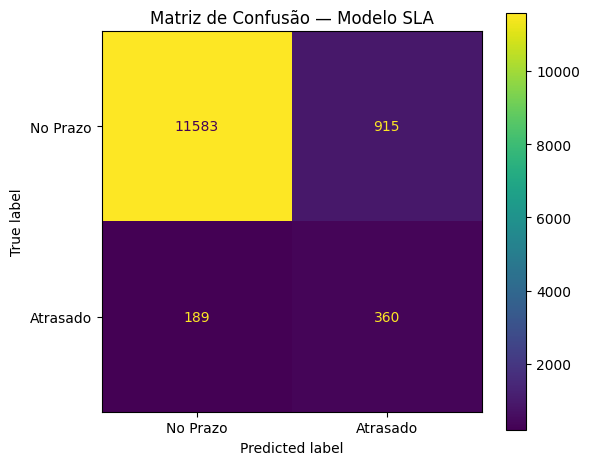

In [86]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predições no conjunto de TESTE (dados nunca vistos)
y_pred_clf = pipeline_classificacao.predict(X_test)

# Classification Report
print("=== Classification Report — Modelo SLA ===")
print(classification_report(y_test, y_pred_clf, target_names=["No Prazo (0)", "Atrasado (1)"]))

# Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clf,
    display_labels=["No Prazo", "Atrasado"], ax=ax)
plt.title("Matriz de Confusão — Modelo SLA")
plt.tight_layout()
plt.show()

In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Split específico para regressão
X_reg = df.drop(columns=["tempo_resolucao_dias", "estourou_sla"])
y_reg = df["tempo_resolucao_dias"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

pipeline_regressao.fit(X_train_r, y_train_r)
y_pred_reg = pipeline_regressao.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))

print(f"MAE:  {mae:.2f} dias  →  o modelo erra em média {mae:.1f} dias")
print(f"RMSE: {rmse:.2f} dias  →  erros grandes são penalizados aqui")

MAE:  5.85 dias  →  o modelo erra em média 5.8 dias
RMSE: 23.36 dias  →  erros grandes são penalizados aqui


In [88]:
import pandas as pd

# Reconstruir X_test com colunas originais para leitura humana
X_test_legivel = X_test.copy()
X_test_legivel['real'] = y_test.values
X_test_legivel['previsto'] = y_pred_clf
X_test_legivel['acertou'] = X_test_legivel['real'] == X_test_legivel['previsto']

# Filtrar: errou na classe 1 (o pior tipo — disse "no prazo" mas era "atrasado")
falsos_negativos = X_test_legivel[
    (X_test_legivel['real'] == 1) & (X_test_legivel['previsto'] == 0)
]

print(f"Total de Falsos Negativos: {len(falsos_negativos)}")
print("\n=== 3 exemplos de erros graves ===")
falsos_negativos[['Distribuidora', 'Tipologia', 'CanalEntrada', 
                   'dia_semana_abertura', 'real', 'previsto']].head(3)

Total de Falsos Negativos: 189

=== 3 exemplos de erros graves ===


,Distribuidora,Tipologia,CanalEntrada,dia_semana_abertura,real,previsto
41897,ELETROPAULO,"Devolução de Val. Cob. a maior, indev., dupl. ...",Local Aneel,1,1,0
5711,COELBA,Faturamento de Mini e Microgeração,Fale Conosco,0,1,0
5382,COPEL,Aferição e Substituição de Medidor,Fale Conosco,4,1,0
